# Task 7 — Understanding the metrics and comparing the three models visually

Inputs: the binary test-set predictions (`predictions/*.png`) and `per_image_metrics.csv`
of the three Task 6 models (U-Net, nnU-Net, DeepLabV3+). Nothing is retrained here.

1. What Dice, IoU and HD95 measure, illustrated on synthetic masks.
2. A per-image error taxonomy for every model: **missed tumour**, **under-segmentation**,
   **over-segmentation**, **inaccurate boundary**.
3. Side-by-side figures: the same test image, ground truth and the three predictions,
   for the most typical and the worst examples of every error type.

## 1. Configuration

Paths, model colours and the thresholds that define each error type.

In [1]:
import os

DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
LABELS_DIR = os.path.join(DATASET_DIR, "labels")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# The three Task 6 models: folder, display name, colour (same colours as in Task 6)
MODELS = {
    "unet":          {"dir": "../task6_unet",          "label": "U-Net",      "color": "#2a78d6"},
    "nnunet":        {"dir": "../task6_nnunet",        "label": "nnU-Net",    "color": "#eb6834"},
    "deeplabv3plus": {"dir": "../task6_deeplabv3plus", "label": "DeepLabV3+", "color": "#1baf7a"},
}
METRICS = ["dice", "iou", "hd95"]

GT_COLOR = "#eda100"     # ground-truth contour colour as in Task 6; drawn dashed here

# ===== Error taxonomy thresholds (per image, per model) =====
# precision = |P∩G| / |P|  (how much of the prediction is tumour)
# recall    = |P∩G| / |G|  (how much of the tumour is found)
MISSED_RECALL_MAX = 0.1     # missed tumour: less than 10% of the tumour is found
UNDER_RECALL_MAX = 0.6      # under-segmentation: 0.1 <= recall < 0.6 ...
UNDER_PRECISION_MIN = 0.8   #   ... while what is predicted is mostly correct
OVER_PRECISION_MAX = 0.6    # over-segmentation: precision < 0.6 ...
OVER_RECALL_MIN = 0.8       #   ... while the tumour itself is mostly covered
BOUNDARY_DICE_MIN = 0.7     # inaccurate boundary: overlap is fine (Dice >= 0.7) ...
BOUNDARY_HD95_MIN = 20.0    #   ... but the boundary strays >= 20 px (95th percentile)
N_EXAMPLES = 4              # rows per category figure

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from medpy.metric import binary as medpy_binary

## 3. Load ground truth, predictions and per-image metrics

Ground-truth masks are loaded with the same rule as in Task 6 (same filename in `labels/`,
any `<stem>_mask*` files merged with OR). We assert that the three CSV files list the test
images in the same order as `test.xlsx`.

In [3]:
test_names = pd.read_excel(TEST_XLSX)["Image"].tolist()
LABEL_FILES = set(os.listdir(LABELS_DIR))


def load_image(name):
    return np.array(Image.open(os.path.join(IMAGES_DIR, name)).convert("L"))


def load_mask(name):
    stem, _ = os.path.splitext(name)
    files = ([name] if name in LABEL_FILES else []) + sorted(f for f in LABEL_FILES if f.startswith(stem + "_mask"))
    m = np.zeros(load_image(name).shape, bool)
    for f in files:
        a = np.array(Image.open(os.path.join(LABELS_DIR, f)))
        m |= (a.max(axis=2) if a.ndim == 3 else a) > 0
    return m


images = {n: load_image(n) for n in test_names}
gts = {n: load_mask(n) for n in test_names}
preds, csvs = {}, {}
for key, info in MODELS.items():
    csvs[key] = pd.read_csv(os.path.join(info["dir"], "per_image_metrics.csv"))
    assert csvs[key]["image_name"].tolist() == test_names, f"{key}: image order differs from test.xlsx"
    preds[key] = {n: np.array(Image.open(os.path.join(info["dir"], "predictions", n))) > 0 for n in test_names}
print(f"{len(test_names)} test images, models: {[m['label'] for m in MODELS.values()]}")

130 test images, models: ['U-Net', 'nnU-Net', 'DeepLabV3+']


## 4. What the three metrics measure

For a prediction P and ground truth G:

| Metric | Formula | Range | Sensitive to |
|---|---|---|---|
| **Dice** | 2\|P∩G\| / (\|P\| + \|G\|) | 0–1, higher better | amount of overlap |
| **IoU** (Jaccard) | \|P∩G\| / \|P∪G\| | 0–1, higher better | overlap, punishes errors harder than Dice |
| **HD95** | 95th percentile of boundary-to-boundary distances (both directions) | 0–∞ px, lower better | *where* the errors are: far-away false positives, jagged or shifted boundaries |

Dice and IoU are two views of the same quantity — **IoU = Dice / (2 − Dice)** — so they
always rank images and models the same way; IoU is just numerically lower. HD95 is a
different kind of metric: it is computed from boundary distances, not pixel counts.
The synthetic example below shows the consequence: a small blob of false positives far
away from the tumour hardly changes Dice, but makes HD95 jump; a uniformly shrunken
prediction loses a lot of Dice but has a small HD95.

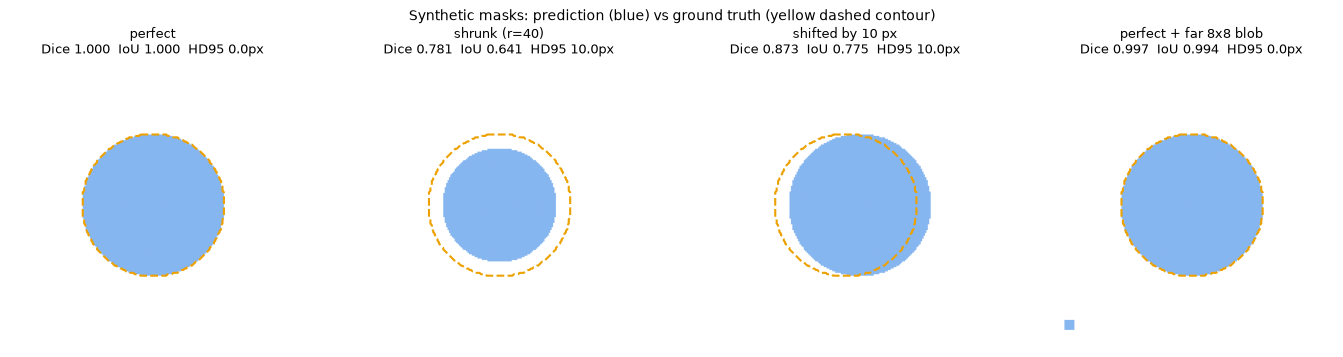

U-Net       max |IoU - Dice/(2-Dice)| = 5.55e-16
nnU-Net     max |IoU - Dice/(2-Dice)| = 3.33e-16
DeepLabV3+  max |IoU - Dice/(2-Dice)| = 4.44e-16


In [4]:
def dice_iou_hd95(p, g):
    inter = (p & g).sum()
    return 2 * inter / (p.sum() + g.sum()), inter / (p | g).sum(), medpy_binary.hd95(p, g)


yy, xx = np.mgrid[:200, :200]
gt_demo = (yy - 100) ** 2 + (xx - 100) ** 2 < 50 ** 2                       # a disc of radius 50
cases = {
    "perfect": gt_demo,
    "shrunk (r=40)": (yy - 100) ** 2 + (xx - 100) ** 2 < 40 ** 2,
    "shifted by 10 px": (yy - 100) ** 2 + (xx - 110) ** 2 < 50 ** 2,
    "perfect + far 8x8 blob": gt_demo | ((yy > 180) & (yy < 188) & (xx > 10) & (xx < 18)),
}
fig, axes = plt.subplots(1, len(cases), figsize=(14, 3.6))
for ax, (title, p) in zip(axes, cases.items()):
    d, j, h = dice_iou_hd95(p, gt_demo)
    ax.imshow(p, cmap=ListedColormap(["white", "#86b6ef"]))
    ax.contour(gt_demo, levels=[0.5], colors=GT_COLOR, linewidths=1.5, linestyles="--")
    ax.set_title(f"{title}\nDice {d:.3f}  IoU {j:.3f}  HD95 {h:.1f}px", fontsize=9)
    ax.axis("off")
fig.suptitle("Synthetic masks: prediction (blue) vs ground truth (yellow dashed contour)", fontsize=10)
fig.tight_layout()
plt.show()

# On the real results, IoU = Dice / (2 - Dice) holds exactly for every image
for key in MODELS:
    c = csvs[key]
    print(f"{MODELS[key]['label']:11s} max |IoU - Dice/(2-Dice)| = {np.abs(c.iou - c.dice / (2 - c.dice)).max():.2e}")

## 5. Error taxonomy for every image and model

From each prediction we compute precision and recall (pixel level) and assign the error
type using the thresholds of the configuration cell. For a given model an image gets at
most one of the first three types (their recall/precision ranges do not overlap);
*inaccurate boundary* requires Dice ≥ 0.7, so in practice it does not coexist with them.

- **missed tumour**: recall < 0.1 — less than 10% of the tumour is covered (empty
  prediction, a prediction somewhere else, or only a few scattered pixels inside it).
- **under-segmentation**: 0.1 ≤ recall < 0.6 but precision ≥ 0.8 — the tumour is found
  but only partly covered.
- **over-segmentation**: precision < 0.6 but recall ≥ 0.8 — the tumour is covered but the
  prediction spills into surrounding tissue (or adds false-positive regions).
- **inaccurate boundary**: Dice ≥ 0.7 (overlap looks fine) but HD95 ≥ 20 px — part of the
  outline is far from the true boundary.

In [5]:
rows = []
for key in MODELS:
    m = csvs[key].set_index("image_name")
    for n in test_names:
        p, g = preds[key][n], gts[n]
        inter = (p & g).sum()
        precision = inter / p.sum() if p.sum() else 0.0
        recall = inter / g.sum()
        r = {"model": key, "image_name": n, "dice": m.loc[n, "dice"], "iou": m.loc[n, "iou"],
             "hd95": m.loc[n, "hd95"], "precision": precision, "recall": recall,
             "area_ratio": p.sum() / g.sum(), "empty": p.sum() == 0}
        r["missed"] = recall < MISSED_RECALL_MAX
        r["under"] = (not r["missed"]) and recall < UNDER_RECALL_MAX and precision >= UNDER_PRECISION_MIN
        r["over"] = (not r["missed"]) and precision < OVER_PRECISION_MAX and recall >= OVER_RECALL_MIN
        r["boundary"] = r["dice"] >= BOUNDARY_DICE_MIN and r["hd95"] >= BOUNDARY_HD95_MIN
        rows.append(r)
tax = pd.DataFrame(rows)
tax.to_csv("error_taxonomy.csv", index=False)

CATEGORIES = {"missed": "missed tumour", "under": "under-segmentation",
              "over": "over-segmentation", "boundary": "inaccurate boundary"}
counts = (tax.groupby("model")[["empty"] + list(CATEGORIES)].sum().astype(int)
          .rename(index={k: v["label"] for k, v in MODELS.items()}, columns=CATEGORIES)
          .rename(columns={"empty": "empty prediction"}))
counts = counts.loc[[v["label"] for v in MODELS.values()]]
print(f"number of test images (out of {len(test_names)}) per error type:")
counts

number of test images (out of 130) per error type:


,empty prediction,missed tumour,under-segmentation,over-segmentation,inaccurate boundary
model,,,,,
U-Net,5,15,13,6,34
nnU-Net,1,5,7,9,45
DeepLabV3+,0,7,6,4,40


## 6. Side-by-side plotting helper

Each row is one test image: the original with the ground-truth contour, then one panel per
model with its prediction (filled in the model colour, solid outline) over the ground-truth
contour (yellow, dashed, so it stays distinguishable from nnU-Net's orange). The panel title gives Dice / HD95; a "◆ <error type>" tag marks the
model(s) that make the error this figure is about.

In [6]:
def overlay(ax, name, pred, color):
    ax.imshow(images[name], cmap="gray")
    if pred is not None and pred.any():
        ax.imshow(np.ma.masked_where(~pred, pred), cmap=ListedColormap([color]), alpha=0.35)
        ax.contour(pred, levels=[0.5], colors=color, linewidths=1.4)
    ax.contour(gts[name], levels=[0.5], colors=GT_COLOR, linewidths=1.6, linestyles="--")
    ax.axis("off")


def compare_figure(names, title, flag=None, filename=None):
    fig, axes = plt.subplots(len(names), 1 + len(MODELS), figsize=(15, 3.5 * len(names)))
    axes = np.atleast_2d(axes)
    for r, n in enumerate(names):
        overlay(axes[r, 0], n, None, None)
        axes[r, 0].set_title(f"{n}\nground truth (yellow dashed)", fontsize=9, loc="left")
        for c, (key, info) in enumerate(MODELS.items(), start=1):
            t = tax[(tax.model == key) & (tax.image_name == n)].iloc[0]
            overlay(axes[r, c], n, preds[key][n], info["color"])
            tag = f"  ◆ {CATEGORIES[flag]}" if flag and t[flag] else ""
            axes[r, c].set_title(f"{info['label']}{tag}\nDice {t.dice:.3f} | HD95 {t.hd95:.1f}px",
                                 fontsize=9, fontweight="bold" if tag else "normal")
    fig.suptitle(title, fontsize=12, y=1.0)
    fig.tight_layout()
    if filename:
        fig.savefig(os.path.join(FIG_DIR, filename), dpi=110, bbox_inches="tight")
    plt.show()

## 7. Typical cases (no cherry-picking)

To show what "normal" performance looks like before looking at failures: the test images
whose mean Dice over the three models is closest to the 25th, 50th and 75th percentile.

mean-Dice 75th percentile: benign (72).png (mean Dice 0.931)
mean-Dice 50th percentile: malignant (1).png (mean Dice 0.879)
mean-Dice 25th percentile: malignant (203).png (mean Dice 0.697)


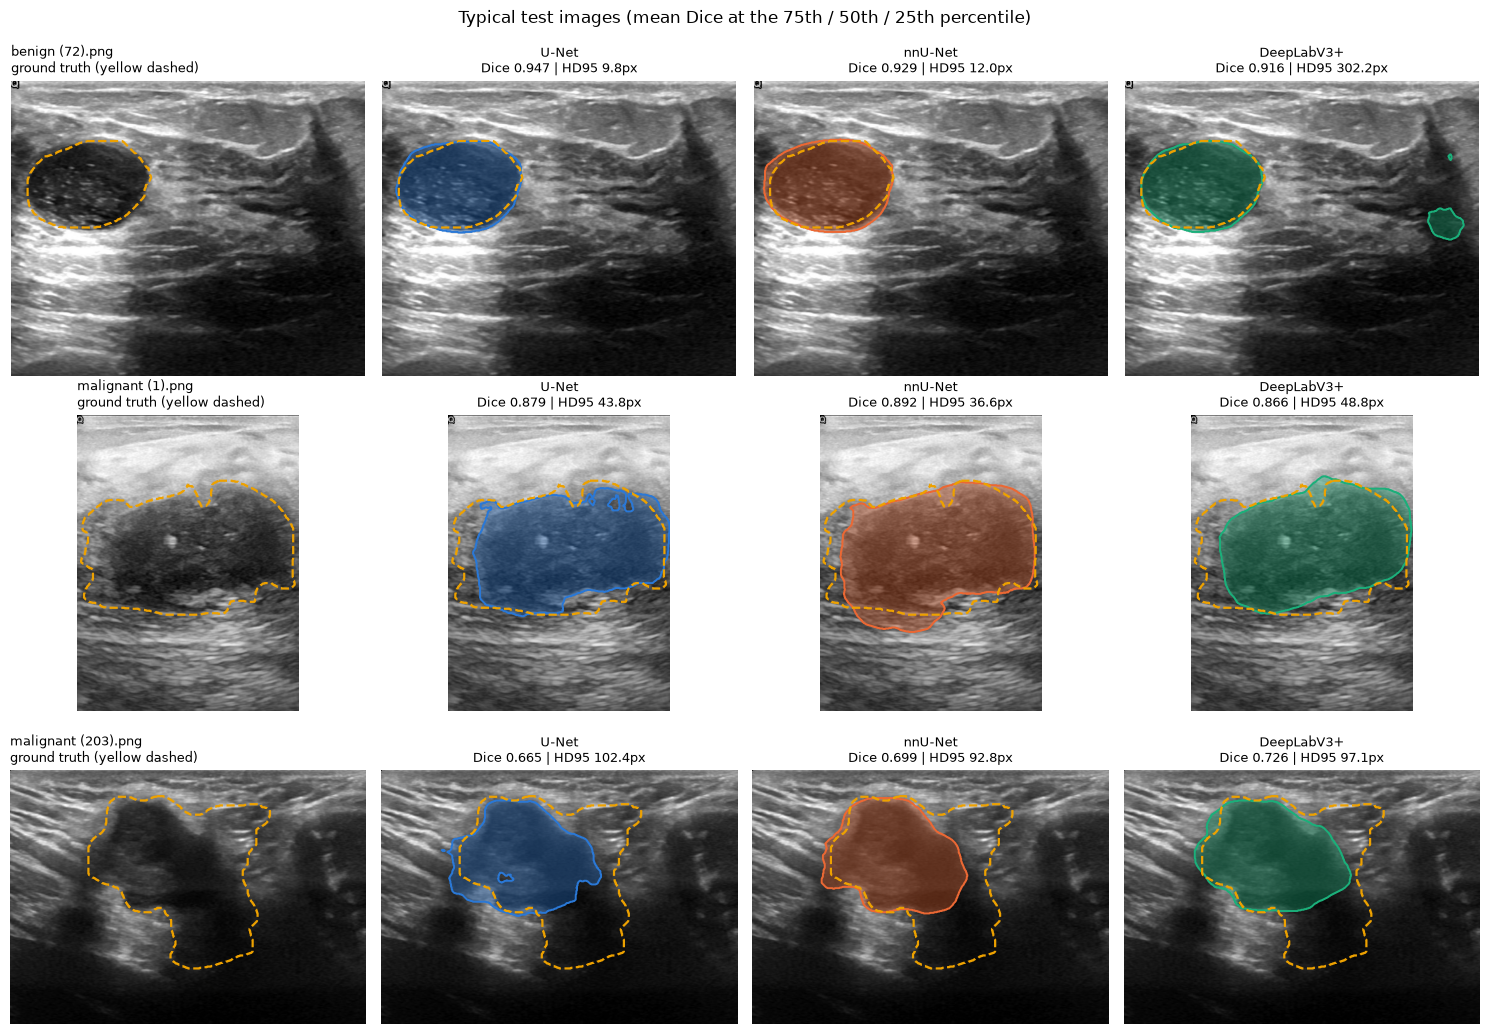

In [7]:
mean_dice = tax.groupby("image_name")["dice"].mean()
typical = []
for q in [0.75, 0.5, 0.25]:
    n = (mean_dice - mean_dice.quantile(q)).abs().idxmin()
    typical.append(n)
    print(f"mean-Dice {int(q * 100)}th percentile: {n} (mean Dice {mean_dice[n]:.3f})")
compare_figure(typical, "Typical test images (mean Dice at the 75th / 50th / 25th percentile)",
               filename="typical_cases.png")

## 8. Failure examples per error type

For every error type we rank the (image, model) pairs that show it by severity and keep the
`N_EXAMPLES` most severe distinct images:

- missed tumour → largest tumours first (the most serious misses),
- under-segmentation → lowest recall,
- over-segmentation → lowest precision,
- inaccurate boundary → highest HD95.

Showing all three models on the same image makes it visible whether a failure is specific to
one model or the image is hard for every model.

missed tumour: malignant (59).png [DeepLabV3+]; malignant (45).png [DeepLabV3+, nnU-Net]; benign (199).png [U-Net, DeepLabV3+, nnU-Net]; benign (395).png [U-Net]


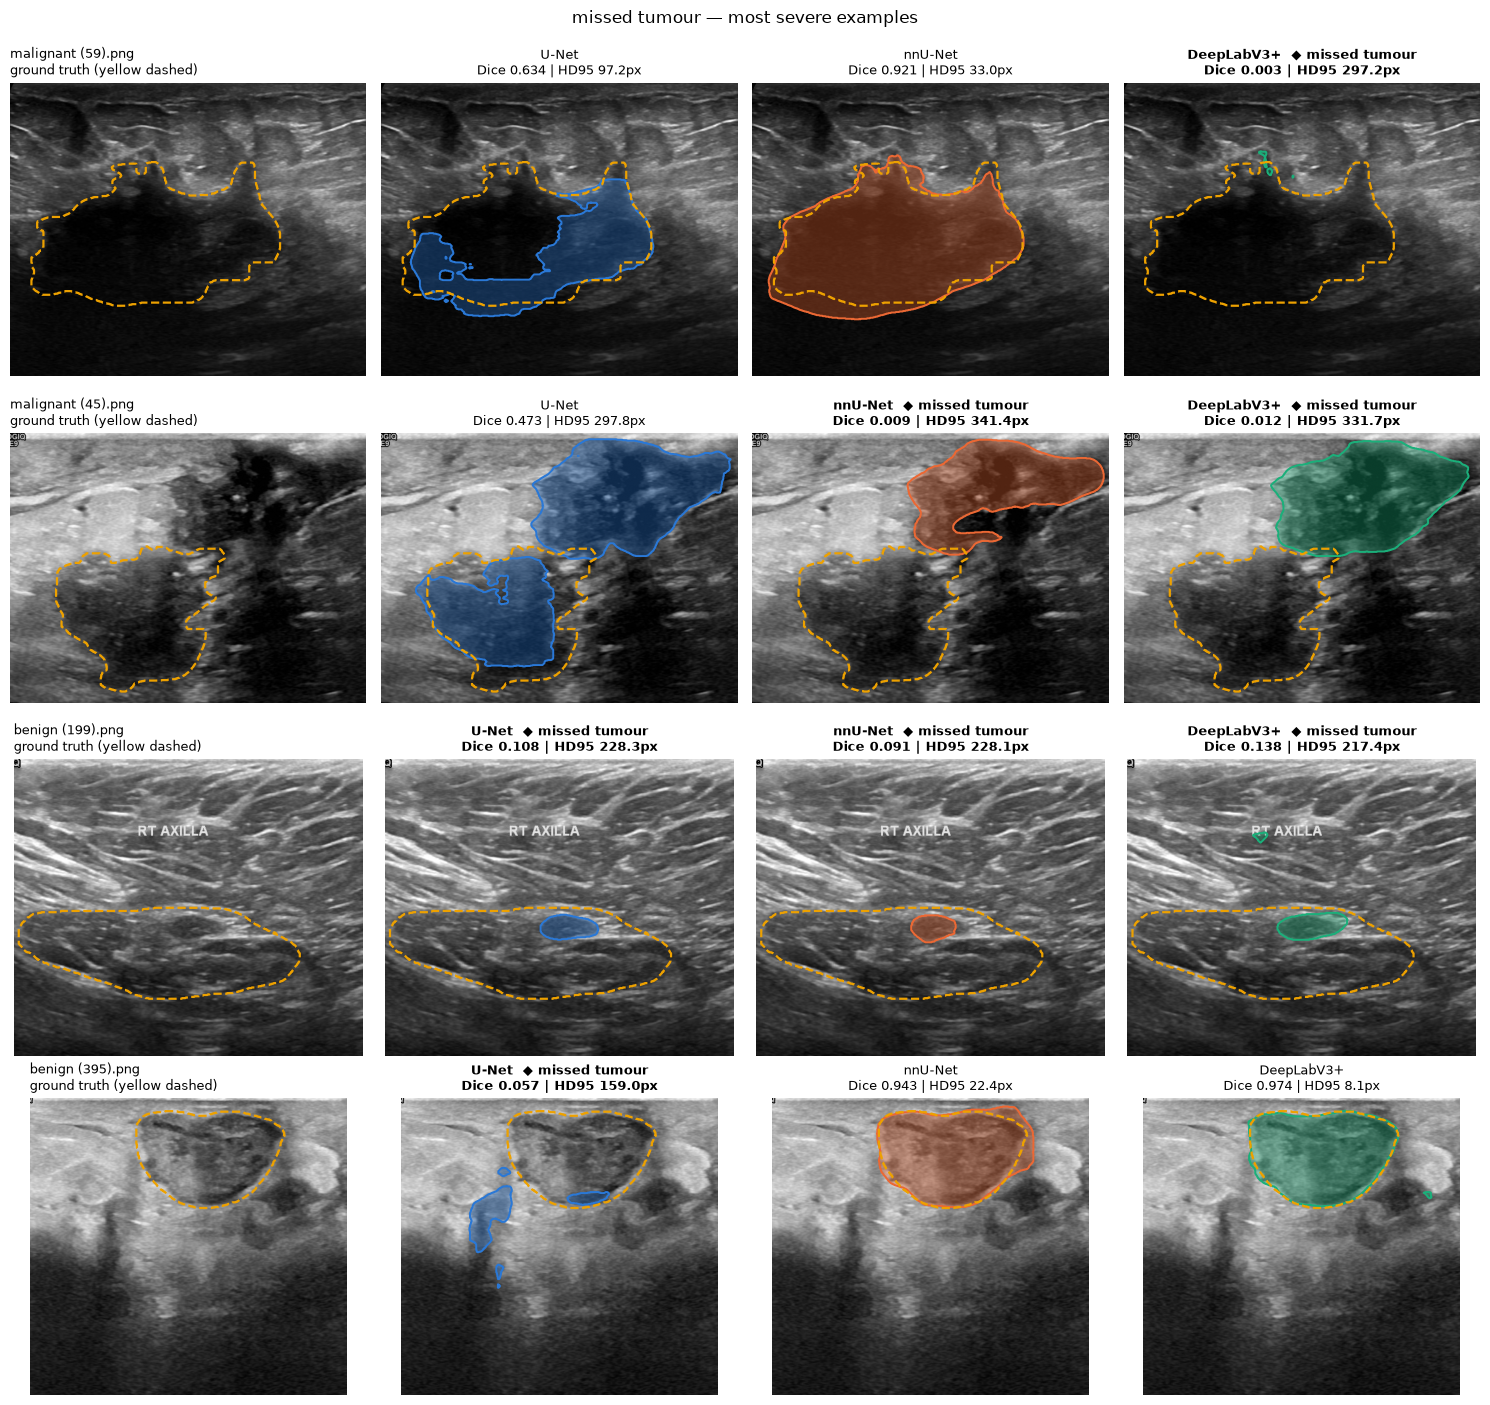

under-segmentation: benign (335).png [U-Net, DeepLabV3+, nnU-Net]; malignant (152).png [DeepLabV3+, nnU-Net]; benign (122).png [DeepLabV3+]; malignant (138).png [U-Net, DeepLabV3+]


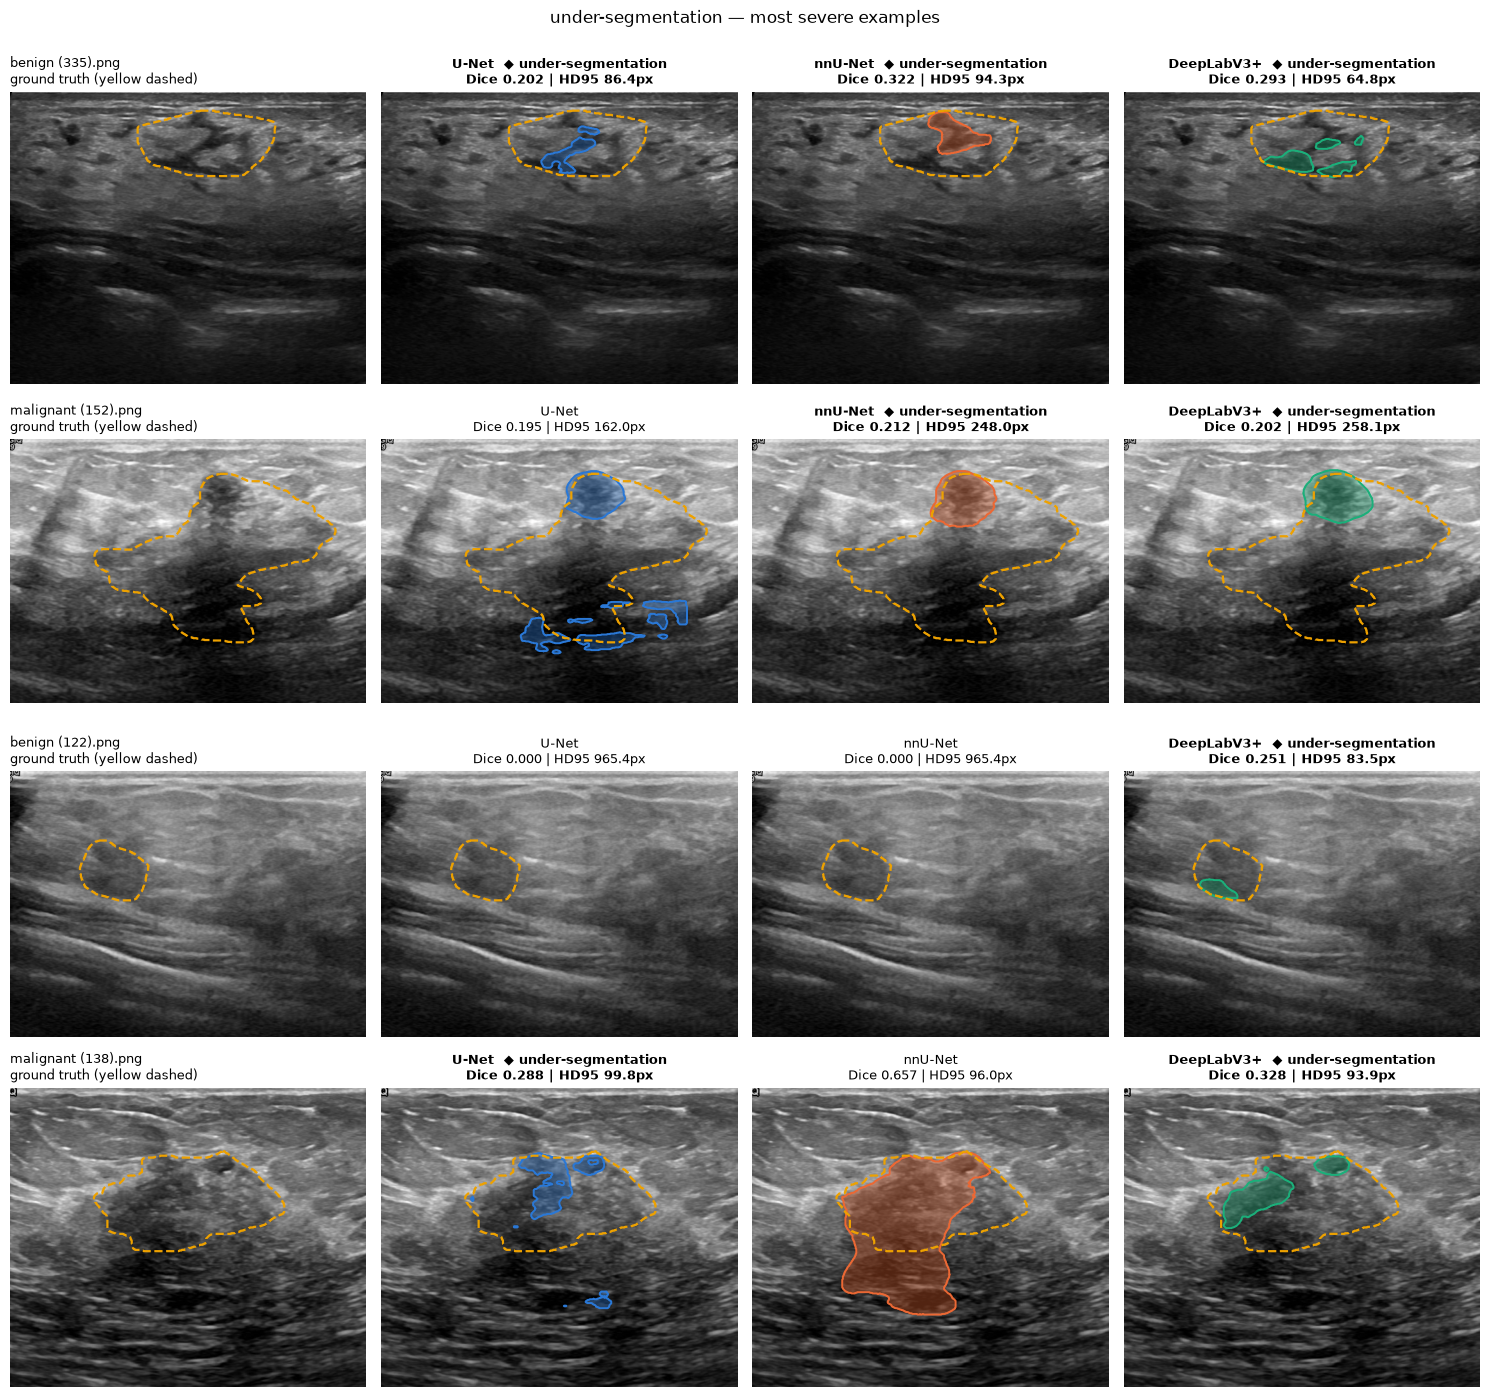

over-segmentation: malignant (157).png [nnU-Net]; benign (144).png [nnU-Net]; benign (169).png [nnU-Net]; benign (427).png [nnU-Net, U-Net, DeepLabV3+]


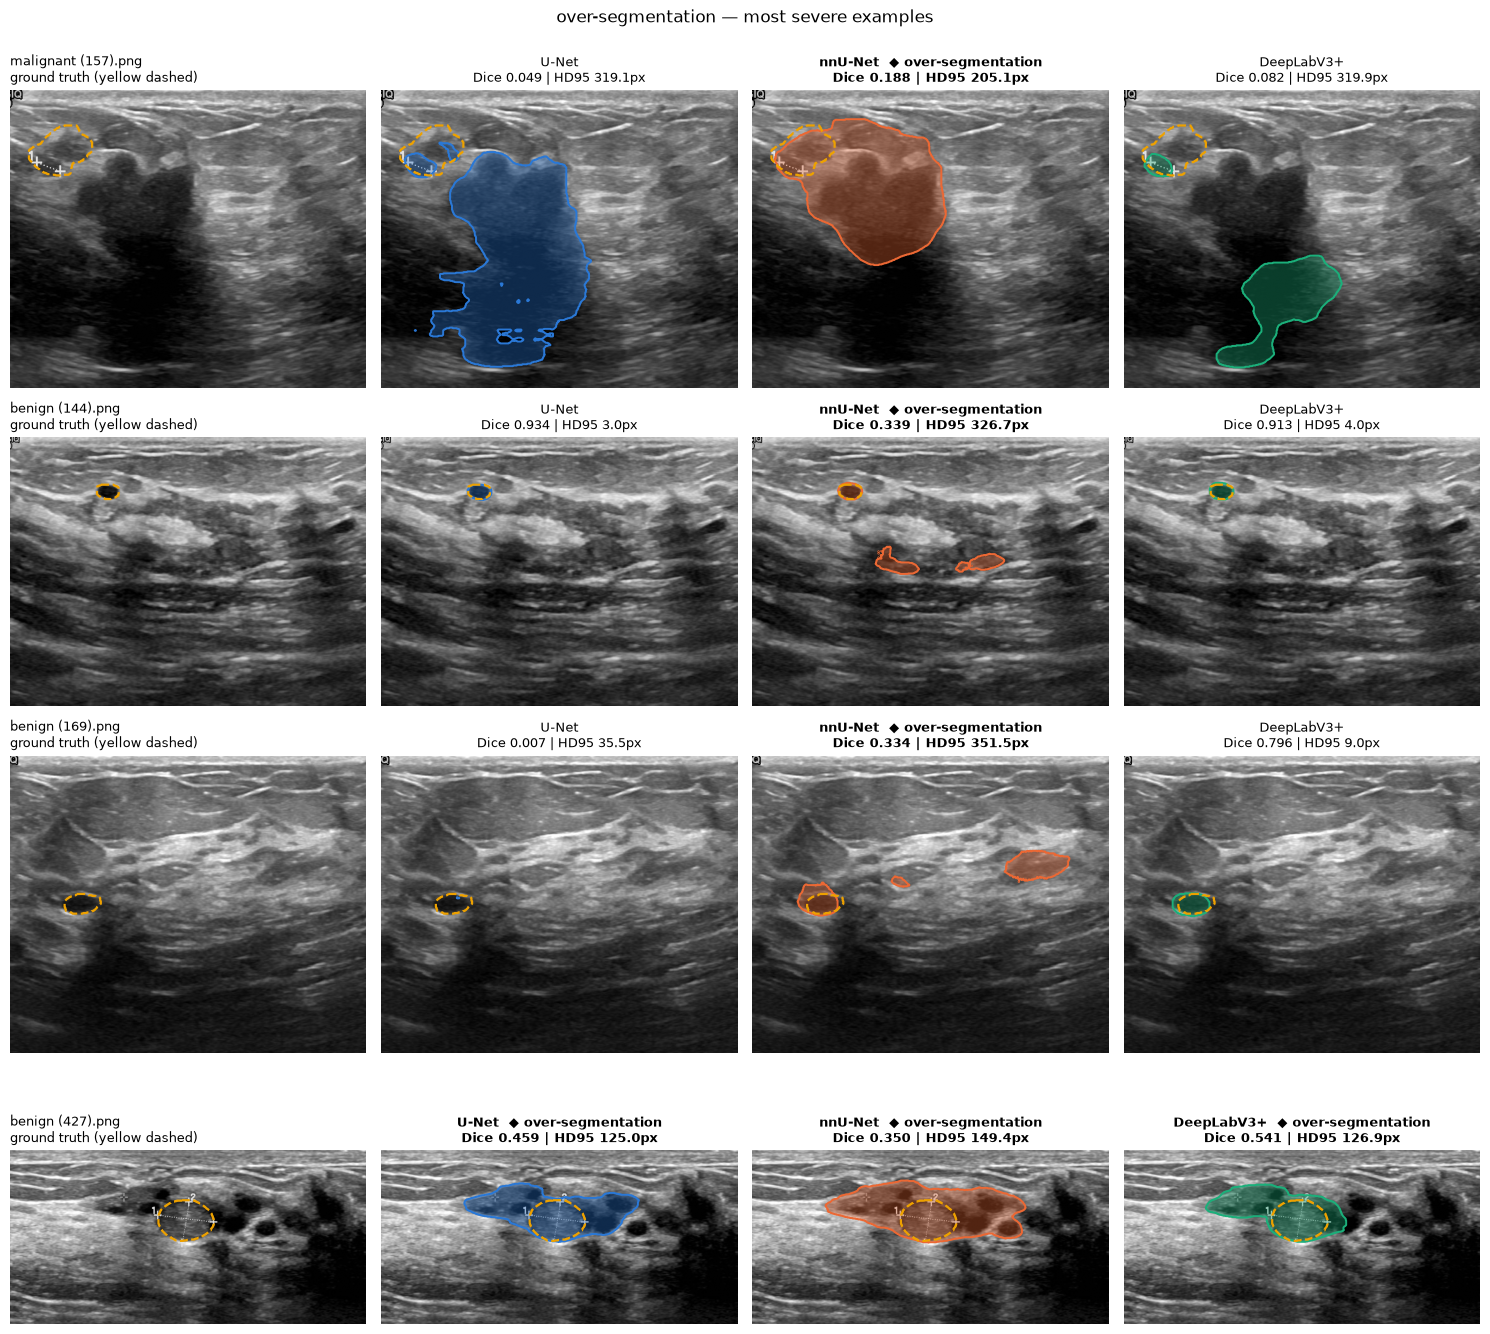

inaccurate boundary: benign (45).png [U-Net, DeepLabV3+, nnU-Net]; benign (72).png [DeepLabV3+]; malignant (55).png [U-Net, nnU-Net]; benign (362).png [DeepLabV3+]


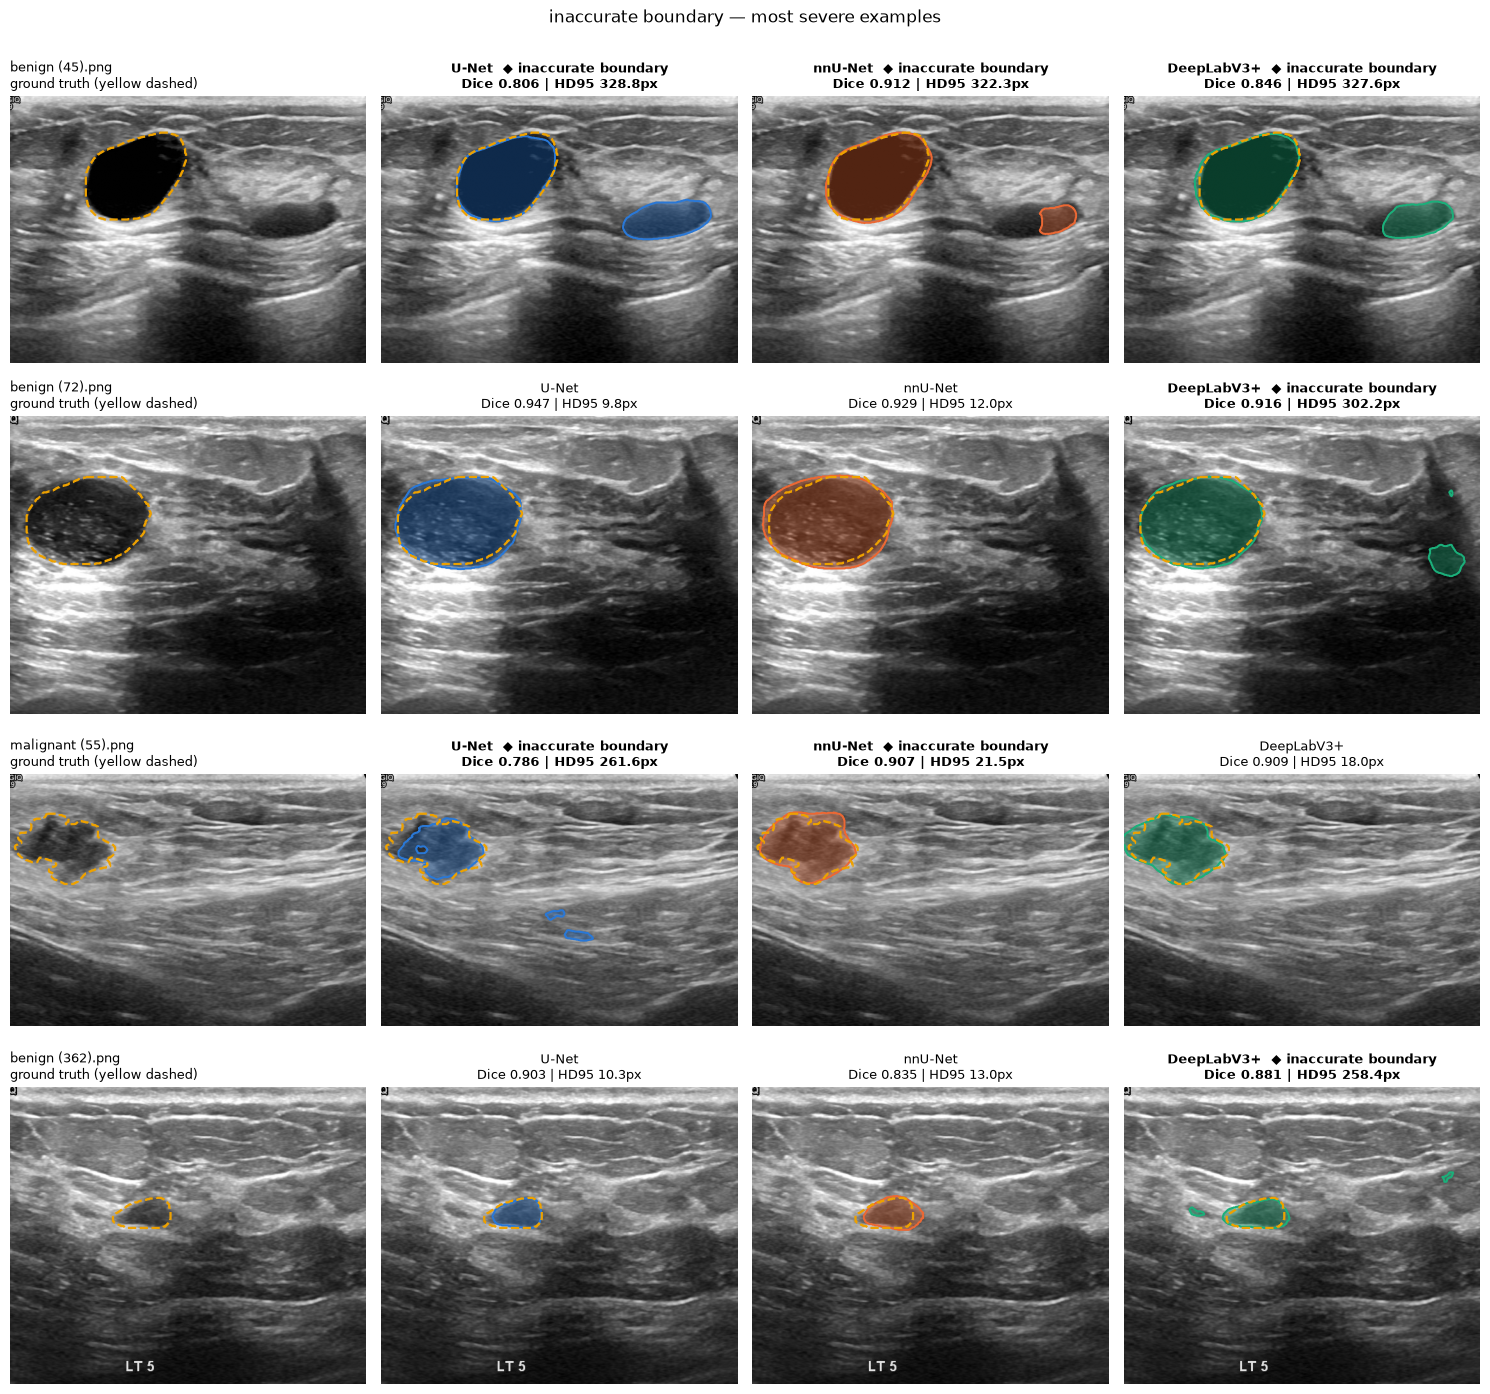

In [8]:
gt_area = pd.Series({n: gts[n].sum() for n in test_names})
SEVERITY = {  # (column to sort by, ascending?)
    "under": ("recall", True), "over": ("precision", True), "boundary": ("hd95", False),
}
selected = {}
for cat, label in CATEGORIES.items():
    hits = tax[tax[cat]].copy()
    if hits.empty:
        print(f"{label}: no example in any model")
        continue
    if cat == "missed":
        hits["sev"] = hits.image_name.map(gt_area)
        hits = hits.sort_values("sev", ascending=False)
    else:
        col, asc = SEVERITY[cat]
        hits = hits.sort_values(col, ascending=asc)
    names = list(dict.fromkeys(hits.image_name))[:N_EXAMPLES]   # distinct images, severity order
    selected[cat] = names
    who = hits.groupby("image_name")["model"].apply(lambda s: ", ".join(MODELS[k]["label"] for k in s))
    print(f"{label}: " + "; ".join(f"{n} [{who[n]}]" for n in names))
    compare_figure(names, f"{label} — most severe examples", flag=cat, filename=f"{cat}_examples.png")

## 9. Summary table of the shown examples

The metrics of every image shown above, for all three models (also saved to
`selected_examples.csv` and used in `segmentation_comparison.md`).

In [9]:
sel_rows = []
for cat, names in [("typical", typical)] + list(selected.items()):
    for n in names:
        row = {"category": cat, "image_name": n}
        for key, info in MODELS.items():
            t = tax[(tax.model == key) & (tax.image_name == n)].iloc[0]
            row[f"{key}_dice"] = round(t.dice, 3)
            row[f"{key}_hd95"] = round(t.hd95, 1)
            row[f"{key}_flag"] = bool(t[cat]) if cat in CATEGORIES else ""
        sel_rows.append(row)
sel = pd.DataFrame(sel_rows)
sel.to_csv("selected_examples.csv", index=False)
pd.set_option("display.width", 200)
sel

,category,image_name,unet_dice,unet_hd95,unet_flag,nnunet_dice,nnunet_hd95,nnunet_flag,deeplabv3plus_dice,deeplabv3plus_hd95,deeplabv3plus_flag
0,typical,benign (72).png,0.947,9.8,,0.929,12.0,,0.916,302.2,
1,typical,malignant (1).png,0.879,43.8,,0.892,36.6,,0.866,48.8,
2,typical,malignant (203).png,0.665,102.4,,0.699,92.8,,0.726,97.1,
3,missed,malignant (59).png,0.634,97.2,False,0.921,33.0,False,0.003,297.2,True
4,missed,malignant (45).png,0.473,297.8,False,0.009,341.4,True,0.012,331.7,True
5,missed,benign (199).png,0.108,228.3,True,0.091,228.1,True,0.138,217.4,True
6,missed,benign (395).png,0.057,159.0,True,0.943,22.4,False,0.974,8.1,False
7,under,benign (335).png,0.202,86.4,True,0.322,94.3,True,0.293,64.8,True
8,under,malignant (152).png,0.195,162.0,False,0.212,248.0,True,0.202,258.1,True
9,under,benign (122).png,0.000,965.4,False,0.000,965.4,False,0.251,83.5,True
